In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

import healpy as hp

In [2]:
params = {'legend.fontsize': 'large',
         'axes.labelsize': 'large',
         'axes.titlesize':'large',
         'xtick.labelsize':'large',
         'ytick.labelsize':'large',
         'figure.facecolor':'w'} 
plt.rcParams.update(params)

In [3]:
min_nobs = 1
# min_dec = -20.

In [4]:
nside = 256
hp_in_desi = np.load('/Users/rongpu/Documents/Data/desi_targets/dr9.0/imaging_sys/misc/in_desi_healpix_ring.npy', allow_pickle=True).item()[str(nside)]

__Randoms__

In [5]:
randoms_density = 2500

randoms_columns = ['RA', 'DEC', 'NOBS_G', 'NOBS_R', 'NOBS_Z', 'MASKBITS', 'PHOTSYS']
randoms = Table(fitsio.read('/Users/rongpu/Documents/Data/dr9/randoms/randoms-1-0.fits', columns=randoms_columns))
lrgmask = Table(fitsio.read('/Users/rongpu/Documents/Data/dr9/randoms/randoms-1-0-lrgmask_v1.fits'))
randoms = hstack([randoms, lrgmask], join_type='exact')

mask = (randoms['NOBS_G']>=min_nobs) & (randoms['NOBS_R']>=min_nobs) & (randoms['NOBS_Z']>=min_nobs)
print(np.sum(mask))
mask &= randoms['lrg_mask']==0
print(np.sum(mask))
# mask &= randoms['DEC']>min_dec
# print(np.sum(mask))

randoms = randoms[mask]
print(len(randoms))

area = len(randoms)/randoms_density
area_north = np.sum(randoms['PHOTSYS']=='N')/randoms_density
area_south = np.sum(randoms['PHOTSYS']=='S')/randoms_density
print('Area:', area)
print('Area (north):', area_north)
print('Area (south):', area_south)

49302231
44991283
44991283
Area: 17996.5132
Area (north): 4526.0072
Area (south): 13470.506


In [6]:
area = len(randoms)/randoms_density
area_north = np.sum(randoms['PHOTSYS']=='N')/randoms_density
area_south = np.sum(randoms['PHOTSYS']=='S')/randoms_density
print('Area:', area)
print('Area (north):', area_north)
print('Area (south):', area_south)

Area: 17996.5132
Area (north): 4526.0072
Area (south): 13470.506


In [7]:
randoms_hpidx = hp.pixelfunc.ang2pix(nside, randoms['RA'], randoms['DEC'], lonlat=True)
randoms_in_desi = np.in1d(randoms_hpidx, hp_in_desi)

In [10]:
area_indesi = np.sum(randoms_in_desi)/randoms_density
area_north = np.sum(randoms['PHOTSYS'][randoms_in_desi]=='N')/randoms_density
area_south = np.sum(randoms['PHOTSYS'][randoms_in_desi]=='S')/randoms_density
print('Area in DESI:', area)
print('Area in DESI (north):', area_north)
print('Area in DESI (south):', area_south)

Area in DESI: 17996.5132
Area in DESI (north): 4173.3084
Area in DESI (south): 9386.1924


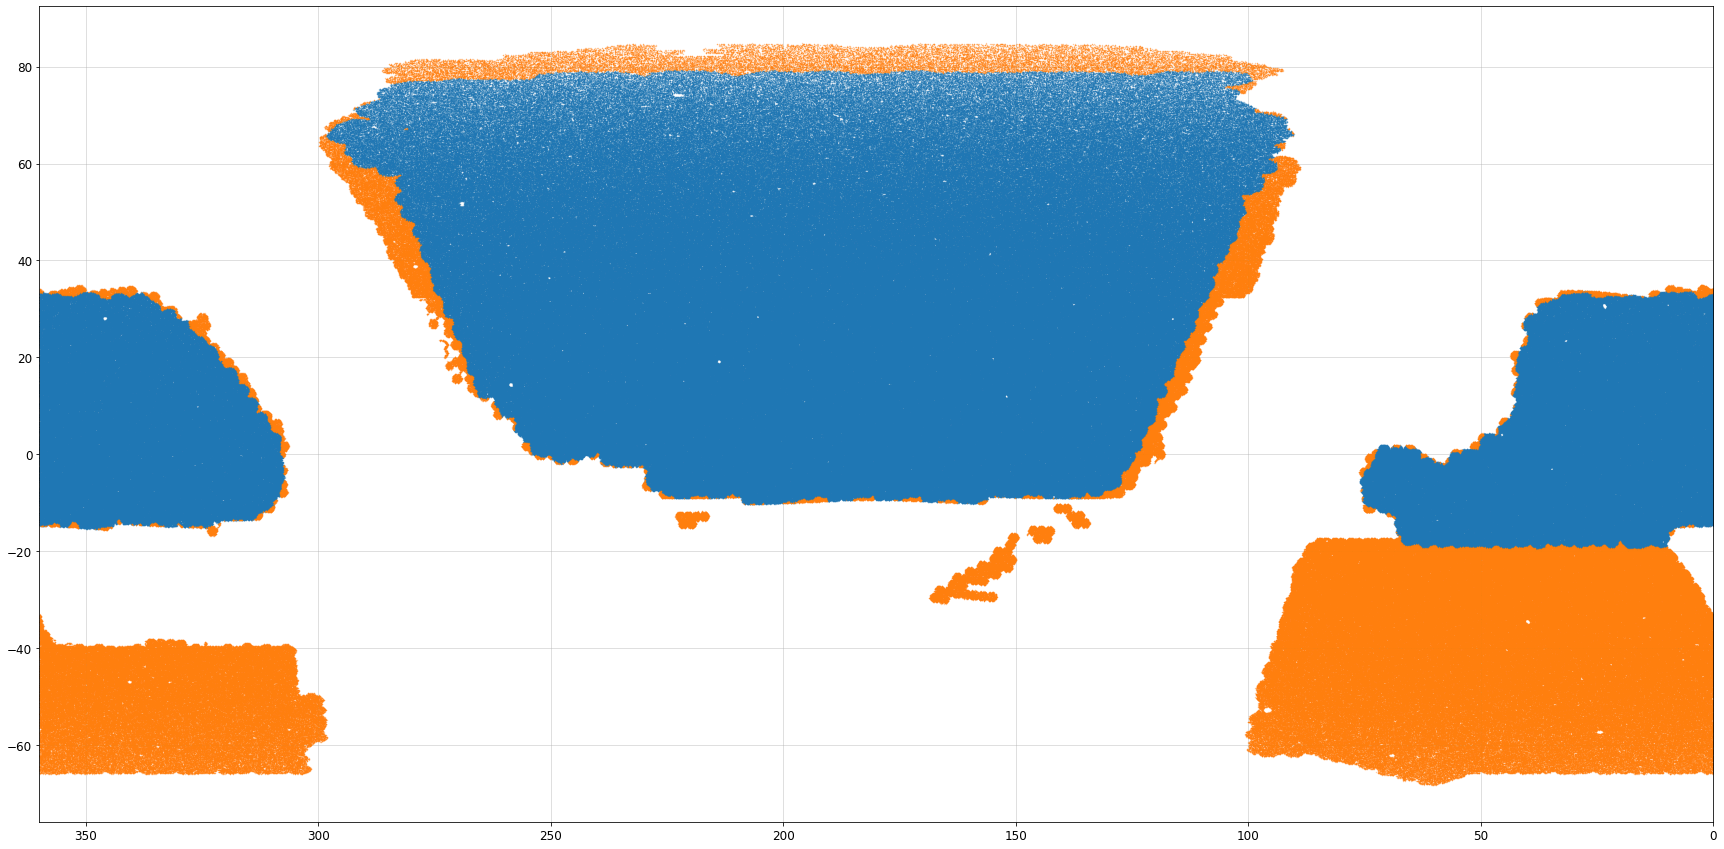

In [9]:
plt.figure(figsize=(30, 15))
plt.plot(randoms['RA'][randoms_in_desi][::10], randoms['DEC'][randoms_in_desi][::10], '.', ms=0.7, alpha=0.5)
plt.plot(randoms['RA'][~randoms_in_desi][::10], randoms['DEC'][~randoms_in_desi][::10], '.', ms=0.7, alpha=0.5)
plt.grid(alpha=0.5)
plt.xlim(360, 0)
plt.show()

__SV1__

In [11]:
cat_stack = []
for field in ['south', 'north']:
    cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/0.49.0/dr9_sv1_lrg_{}_0.49.0_basic.fits'.format(field)))
    lrgmask = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/0.49.0/dr9_sv1_lrg_{}_0.49.0_lrgmask_v1.fits'.format(field)))
    cat = hstack([cat, lrgmask], join_type='exact')
    cat_stack.append(cat)
cat = vstack(cat_stack)
print(len(cat))

mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
print(np.sum(mask))
mask &= cat['lrg_mask']==0
print(np.sum(mask))
# mask &= cat['DEC']>min_dec
# print(np.sum(mask))

cat = cat[mask]
print(len(cat))

42464101
42464101
37804081
37804081


In [12]:
hpidx = hp.pixelfunc.ang2pix(nside, cat['RA'], cat['DEC'], lonlat=True)
in_desi = np.in1d(hpidx, hp_in_desi)
cat = cat[in_desi]
print(len(cat))

28683435


In [17]:
# plt.figure(figsize=(30, 15))
# plt.plot(cat['RA'][::10], cat['DEC'][::10], '.', ms=0.7, alpha=0.5)
# plt.grid(alpha=0.5)
# plt.xlim(360, 0)
# plt.show()

In [14]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

print('Density: {:.2f}'.format(len(cat)/area))
print('Density (north): {:.2f}'.format(np.sum(mask_north)/area_north))
print('Density (south): {:.2f}'.format(np.sum(mask_south)/area_south))

Density: 1593.83
Density (north): 2109.38
Density (south): 2118.04


In [15]:
# QSO overlap
mask = cat['SV1_DESI_TARGET'] & 2**2>0
print('QSO overlap: {:.2f}%'.format(np.sum(mask)/len(cat)*100))
print('QSO overlap (north): {:.2f}%'.format(np.sum(mask & mask_north)/np.sum(mask_north)*100))
print('QSO overlap (south): {:.2f}%'.format(np.sum(mask & mask_south)/np.sum(mask_south)*100))

QSO overlap: 1.02%
QSO overlap (north): 0.96%
QSO overlap (south): 1.05%


In [18]:
sv1 = cat.copy()

__SV3__

In [19]:
cat_stack = []
for field in ['south', 'north']:
    cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/0.57.0/dr9_sv3_lrg_{}_0.57.0_basic.fits'.format(field)))
    lrgmask = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/0.57.0/dr9_sv3_lrg_{}_0.57.0_lrgmask_v1.fits'.format(field)))
    cat = hstack([cat, lrgmask], join_type='exact')
    cat_stack.append(cat)
cat = vstack(cat_stack)
print(len(cat))

mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
print(np.sum(mask))
mask &= cat['lrg_mask']==0
print(np.sum(mask))
# mask &= cat['DEC']>min_dec
# print(np.sum(mask))

cat = cat[mask]
print(len(cat))

16258498
16258498
14337982
14337982


In [20]:
hpidx = hp.pixelfunc.ang2pix(nside, cat['RA'], cat['DEC'], lonlat=True)
in_desi = np.in1d(hpidx, hp_in_desi)
cat = cat[in_desi]
print(len(cat))

10883069


In [21]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

print('Density: {:.2f}'.format(len(cat)/area))
print('Density (north): {:.2f}'.format(np.sum(mask_north)/area_north))
print('Density (south): {:.2f}'.format(np.sum(mask_south)/area_south))

Density: 604.73
Density (north): 802.01
Density (south): 802.89


In [22]:
# QSO overlap
mask = cat['SV3_DESI_TARGET'] & 2**2>0
print('QSO overlap: {:.2f}%'.format(np.sum(mask)/len(cat)*100))
print('QSO overlap (north): {:.2f}%'.format(np.sum(mask & mask_north)/np.sum(mask_north)*100))
print('QSO overlap (south): {:.2f}%'.format(np.sum(mask & mask_south)/np.sum(mask_south)*100))

QSO overlap: 0.55%
QSO overlap (north): 0.48%
QSO overlap (south): 0.58%


In [23]:
np.sum(~np.in1d(cat['TARGETID'], sv1['TARGETID']))

6

__Main__

In [24]:
cat_stack = []
for field in ['south', 'north']:
    cat = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_lrg_{}_1.0.0_basic.fits'.format(field)))
    lrgmask = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_targets/dr9.0/combined/1.0.0/dr9_lrg_{}_1.0.0_lrgmask_v1.fits'.format(field)))
    cat = hstack([cat, lrgmask], join_type='exact')
    cat_stack.append(cat)
cat = vstack(cat_stack)
print(len(cat))

mask = (cat['NOBS_G']>=min_nobs) & (cat['NOBS_R']>=min_nobs) & (cat['NOBS_Z']>=min_nobs)
print(np.sum(mask))
mask &= cat['lrg_mask']==0
print(np.sum(mask))
# mask &= cat['DEC']>min_dec
# print(np.sum(mask))

cat = cat[mask]
print(len(cat))

12338990
12338990
10817704
10817704


In [25]:
hpidx = hp.pixelfunc.ang2pix(nside, cat['RA'], cat['DEC'], lonlat=True)
in_desi = np.in1d(hpidx, hp_in_desi)
cat = cat[in_desi]
print(len(cat))

8207587


In [26]:
mask_north = cat['PHOTSYS']=='N'
mask_south = cat['PHOTSYS']=='S'

print('Density: {:.2f}'.format(len(cat)/area))
print('Density (north): {:.2f}'.format(np.sum(mask_north)/area_north))
print('Density (south): {:.2f}'.format(np.sum(mask_south)/area_south))

Density: 456.07
Density (north): 603.74
Density (south): 606.00


In [27]:
# QSO overlap
mask = cat['DESI_TARGET'] & 2**2>0
print('QSO overlap: {:.2f}%'.format(np.sum(mask)/len(cat)*100))
print('QSO overlap (north): {:.2f}%'.format(np.sum(mask & mask_north)/np.sum(mask_north)*100))
print('QSO overlap (south): {:.2f}%'.format(np.sum(mask & mask_south)/np.sum(mask_south)*100))

QSO overlap: 0.62%
QSO overlap (north): 0.55%
QSO overlap (south): 0.65%


In [28]:
np.sum(~np.in1d(cat['TARGETID'], sv1['TARGETID']))

3